In [ ]:
# ============================================
# Speech Denoising with Remote-Channel Degradation Simulation
# - Injection degradation during the data loading stage: background noise, packet loss, echo, multipath, telephone band limit, codec artifacts
# - UNet mask Estimation (Spectral Domain)
# - Training assessment + trial listening + indicator visualization (Common indicators of ICASSP)
# ============================================

# %pip install -q soundfile librosa torch torchvision torchaudio matplotlib pandas

import os, math, random, time
from pathlib import Path
import numpy as np
import soundfile as sf
import librosa
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from IPython.display import Audio, display

# ==== Data path (modify/keep consistent according to your local path) ====
CLEAN_TR = r"D:\GitHub\ELEC5305_dataset\clean_trainset_28spk_wav"
NOISY_TR = r"D:\GitHub\ELEC5305_dataset\noisy_trainset_28spk_wav"   
CLEAN_TE = r"D:\GitHub\ELEC5305_dataset\clean_testset_wav"
NOISY_TE = r"D:\GitHub\ELEC5305_dataset\noisy_testset_wav"         

# ==== Sampling rate and fragment length ====
TARGET_SR = 16000
SEGMENT_SEC = 2.0
SEGMENT_SAM = int(TARGET_SR * SEGMENT_SEC)

# ==== STFT parameter ====
N_FFT = 512
HOP   = 128
WIN   = N_FFT
WINDOW = torch.hann_window(WIN)

# ==== Training hyperparameters ====
BATCH_SIZE = 8
LR = 2e-3
EPOCHS = 10
LAMBDA_SISDR = 1.0
LAMBDA_SPEC  = 0.2

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

# ====== Control the training logarithm and random seed ======
MAX_TRAIN_PAIRS   = 500   
PAIR_SUBSET_SEED  = 2025

Device: cuda


Train pairs: 11572

Eval pairs: 824

In [ ]:
# ===========================
# Remote-channel degradation 
# ===========================
def mu_law_encode(x, mu=255.0):
    x = np.clip(x, -1.0, 1.0)
    return np.sign(x) * np.log1p(mu * np.abs(x)) / np.log1p(mu)

def mu_law_decode(y, mu=255.0):
    return np.sign(y) * (1.0 / mu) * (np.expm1(np.log1p(mu) * np.abs(y)))

def colored_noise(N, color="white", a=0.985, seed=None):
    rng = np.random.default_rng(seed)
    x = rng.standard_normal(N).astype(np.float32)
    if color == "white":
        return x
    y = np.zeros_like(x)
    for n in range(N):
        y[n] = a * (y[n-1] if n > 0 else 0.0) + (1 - a) * x[n]
    if color == "pink":
        return y
    if color == "brown":
        z = np.zeros_like(y)
        for n in range(N):
            z[n] = a * (z[n-1] if n > 0 else 0.0) + (1 - a) * y[n]
        return z
    return x

def add_background_noise(x, snr_db_range=(0, 20), mode="mix", seed=None):
    rng = np.random.default_rng(seed)
    N = len(x)
    if mode == "mix":
        color = rng.choice(["white", "pink", "brown"])
        n = colored_noise(N, color=color, seed=seed)
    elif mode == "speechbleed":
        n = x.copy()
        rng.shuffle(n)
        n = colored_noise(N, color="pink", seed=seed) * 0.6 + n * 0.4
    else:
        n = colored_noise(N, color="white", seed=seed)
    snr_db = rng.uniform(*snr_db_range)
    Px = np.mean(x.astype(np.float64)**2) + 1e-12
    Pn_target = Px / (10**(snr_db/10.0))
    Pn = np.mean(n.astype(np.float64)**2) + 1e-12
    n = n * np.sqrt(Pn_target / Pn)
    y = x + n.astype(np.float32)
    return y

def packet_loss(x, sr, frame_ms=20, loss_rate=0.05, burst_prob=0.3, mode="zero", seed=None):
    rng = np.random.default_rng(seed)
    L = max(1, int(sr * frame_ms / 1000.0))
    T = (len(x) + L - 1) // L
    x2 = x.astype(np.float32).copy()

    # Independent packet loss
    lose = rng.random(T) < loss_rate

    # Sudden packet loss (40 to 160ms, or 2 to 8 frames)
    if rng.random() < burst_prob and T > 4:
        start = rng.integers(0, T - 3)
        span  = rng.integers(2, min(8, T - start))
        lose[start:start + span] = True

    last_good = None  # Save the previous frame (by "actual frame length")
    for t in range(T):
        s = t * L
        e = min(len(x2), s + L)
        seg_len = e - s  # The actual length of this section (the last section may be less than L)

        if lose[t]:
            if mode == "zero" or last_good is None:
                x2[s:e] = 0.0
            else:
                # Replace it with the content of the previous frame, but truncate it to the actual length of this section
                x2[s:e] = last_good[:seg_len]
        else:
            # Record the current "good frame" with a length consistent with this segment (to avoid a mismatch in the length of the next segment)
            last_good = x2[s:e].copy()

    return x2

def echo_ir(sr, delays_ms=(20, 120), taps_range=(1, 3), decay_range=(0.25, 0.7), seed=None):
    rng = np.random.default_rng(seed)
    taps = rng.integers(taps_range[0], taps_range[1]+1)
    max_delay = int(sr * (delays_ms[1] / 1000.0)) + 1
    h = np.zeros(max_delay + 1, dtype=np.float32)
    h[0] = 1.0
    for _ in range(taps):
        d_ms = rng.uniform(*delays_ms)
        d = int(sr * d_ms / 1000.0)
        if d == 0: d = 1
        decay = rng.uniform(*decay_range)
        h[d] += decay
    if np.max(np.abs(h)) > 1.0:
        h = h / np.max(np.abs(h))
    return h

def apply_fir(x, h):
    y = np.convolve(x.astype(np.float32), h.astype(np.float32), mode="full")[:len(x)]
    y = np.clip(y, -3.0, 3.0)
    return y.astype(np.float32)

def bandlimit_stft(x, sr, f_lo=300.0, f_hi=3400.0, n_fft=512, hop=128, win=512):
    X = librosa.stft(x, n_fft=n_fft, hop_length=hop, win_length=win)
    freqs = librosa.fft_frequencies(sr=sr, n_fft=n_fft)
    mask = (freqs >= f_lo) & (freqs <= f_hi)
    M = mask[:, None].astype(np.float32)
    Y = X * M
    y = librosa.istft(Y, hop_length=hop, win_length=win, length=len(x))
    return y.astype(np.float32)

def codec_artifact(x, sr, low_sr=8000, mu=255.0):
    y = librosa.resample(x.astype(np.float32), orig_sr=sr, target_sr=low_sr)
    y = librosa.resample(y.astype(np.float32), orig_sr=low_sr, target_sr=sr)
    y_mu = mu_law_decode(mu_law_encode(y, mu=mu), mu=mu)
    L = min(len(x), len(y_mu))
    out = np.zeros_like(x)
    out[:L] = y_mu[:L]
    if L < len(out):
        out[L:] = y_mu[-1]
    return out.astype(np.float32)

class RemoteChannelAugmentor:
    def __init__(self,
                 snr_db_range=(0, 20),
                 noise_mode_choices=("mix", "speechbleed"),
                 packet_loss_rate=(0.0, 0.15),
                 packet_burst_prob=0.4,
                 packet_mode_choices=("zero", "hold"),
                 echo_delays_ms=(20, 160),
                 echo_taps=(1, 3),
                 echo_decay=(0.2, 0.8),
                 bandlimit_prob=0.7,
                 codec_prob=0.7,
                 seed=None):
        self.snr_db_range = snr_db_range
        self.noise_mode_choices = noise_mode_choices
        self.packet_loss_rate = packet_loss_rate
        self.packet_burst_prob = packet_burst_prob
        self.packet_mode_choices = packet_mode_choices
        self.echo_delays_ms = echo_delays_ms
        self.echo_taps = echo_taps
        self.echo_decay = echo_decay
        self.bandlimit_prob = bandlimit_prob
        self.codec_prob = codec_prob
        self.rng = np.random.default_rng(seed)

    def __call__(self, x, sr):
        rng = self.rng
        y = x.astype(np.float32).copy()
        if rng.random() < self.codec_prob:
            y = codec_artifact(y, sr)
        if rng.random() < self.bandlimit_prob:
            f_lo = rng.uniform(200.0, 400.0)
            f_hi = rng.uniform(3200.0, 3800.0)
            f_lo, f_hi = min(f_lo, f_hi-200.0), max(f_hi, f_lo+200.0)
            y = bandlimit_stft(y, sr, f_lo=f_lo, f_hi=f_hi, n_fft=512, hop=128, win=512)
        h = echo_ir(sr, delays_ms=self.echo_delays_ms, taps_range=self.echo_taps,
                    decay_range=self.echo_decay, seed=rng.integers(1e9))
        y = apply_fir(y, h)
        noise_mode = rng.choice(self.noise_mode_choices)
        y = add_background_noise(y, snr_db_range=self.snr_db_range, mode=noise_mode,
                                 seed=rng.integers(1e9))
        loss_rate = rng.uniform(*self.packet_loss_rate)
        plc_mode  = rng.choice(self.packet_mode_choices)
        y = packet_loss(y, sr, frame_ms=20, loss_rate=loss_rate,
                        burst_prob=self.packet_burst_prob, mode=plc_mode,
                        seed=rng.integers(1e9))
        y = np.clip(y, -1.0, 1.0).astype(np.float32)
        return y

# ===========================
# I/O tools
# ===========================
def read_mono_resample(path, target_sr=16000):
    y, sr = sf.read(path, always_2d=False)
    if y.ndim == 2:
        y = y.mean(axis=1)
    if sr != target_sr:
        y = librosa.resample(y.astype(np.float32), orig_sr=sr, target_sr=target_sr)
        sr = target_sr
    y = y.astype(np.float32)
    return y, sr

def pad_or_trim(x, length):
    if len(x) >= length:
        start = np.random.randint(0, len(x) - length + 1)
        return x[start:start+length]
    out = np.zeros(length, dtype=np.float32)
    out[:len(x)] = x
    return out

In [ ]:
# ===========================
# Dataset
# ===========================
class VBDataset(Dataset):
    def __init__(self, noisy_dir, clean_dir, target_sr=16000, segment_sam=None,
                 train=True, max_pairs=None,
                 use_synth_remote=False, synth_prob=1.0, augmentor=None):
        self.noisy_dir = Path(noisy_dir) if (noisy_dir is not None) else None
        self.clean_dir = Path(clean_dir)
        self.segment_sam = segment_sam
        self.target_sr = target_sr
        self.train = train
        self.max_pairs = max_pairs
        self.use_synth_remote = use_synth_remote
        self.synth_prob = synth_prob
        self.augmentor = augmentor if augmentor is not None else RemoteChannelAugmentor()

        if self.noisy_dir is not None and self.noisy_dir.exists():
            noisy_files = sorted(list(self.noisy_dir.glob("*.wav")))
        else:
            noisy_files = []

        pairs = []
        if noisy_files:
            for nf in noisy_files:
                cf = self.clean_dir / nf.name
                if cf.exists():
                    pairs.append((nf, cf))
        else:
            clean_files = sorted(list(self.clean_dir.glob("*.wav")))
            for cf in clean_files:
                pairs.append((None, cf))

        if not pairs:
            raise RuntimeError("No samples were found. Please check the path (at least there should be a clean file).")

        if self.train and (self.max_pairs is not None) and (len(pairs) > self.max_pairs):
            rng = np.random.default_rng(PAIR_SUBSET_SEED)
            idx = rng.choice(len(pairs), size=self.max_pairs, replace=False)
            self.pairs = [pairs[i] for i in idx]
            print(f"Train pairs: {len(self.pairs)} / {len(pairs)} (subset with seed={PAIR_SUBSET_SEED})")
        else:
            self.pairs = pairs
            print(f"{'Train' if train else 'Eval'} pairs:", len(self.pairs))

    def __len__(self):
        return len(self.pairs)

    def _read_one(self, nf, cf):
        clean, _ = read_mono_resample(cf, self.target_sr)
        use_synth = (self.train and self.use_synth_remote and (np.random.rand() < self.synth_prob))
        if (not use_synth) and (nf is not None):
            noisy, _ = read_mono_resample(nf, self.target_sr)
            L = min(len(noisy), len(clean))
            noisy = noisy[:L]; clean = clean[:L]
        else:
            noisy = self.augmentor(clean, self.target_sr)
            L = min(len(noisy), len(clean))
            noisy = noisy[:L]; clean = clean[:L]
        return noisy.astype(np.float32), clean.astype(np.float32)

    def __getitem__(self, idx):
        nf, cf = self.pairs[idx]
        noisy, clean = self._read_one(nf, cf)
        if self.train and self.segment_sam is not None:
            L = min(len(noisy), len(clean))
            if L >= self.segment_sam:
                start = np.random.randint(0, L - self.segment_sam + 1)
                noisy = noisy[start:start+self.segment_sam]
                clean = clean[start:start+self.segment_sam]
            else:
                noisy = pad_or_trim(noisy, self.segment_sam)
                clean = pad_or_trim(clean, self.segment_sam)
        else:
            L = min(len(noisy), len(clean))
            noisy = noisy[:L]; clean = clean[:L]
        return torch.from_numpy(noisy), torch.from_numpy(clean)

# ==== Build the dataset & degenerate ====
my_aug = RemoteChannelAugmentor(
    snr_db_range=(0, 20),
    packet_loss_rate=(0.0, 0.15),
    packet_burst_prob=0.5,
    bandlimit_prob=0.8,
    codec_prob=0.8
)

train_ds = VBDataset(
    NOISY_TR, CLEAN_TR,
    target_sr=TARGET_SR,
    segment_sam=SEGMENT_SAM,
    train=True,
    max_pairs=MAX_TRAIN_PAIRS,
    use_synth_remote=True,   
    synth_prob=0.5,          
    augmentor=my_aug
)
test_ds  = VBDataset(
    NOISY_TE, CLEAN_TE,
    target_sr=TARGET_SR,
    segment_sam=None,
    train=False,
    max_pairs=None,
    use_synth_remote=True,   
    synth_prob=1.0,
    augmentor=my_aug
)

train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, drop_last=True)
test_dl  = DataLoader(test_ds,  batch_size=1, shuffle=False, num_workers=0)

Train pairs: 500 / 11572 (subset with seed=2025)
Eval pairs: 824


In [ ]:
# ===========================
# Model: UNet mask
# ===========================
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch, k=3, p=1):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, k, padding=p),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Conv2d(out_ch, out_ch, k, padding=p),
            nn.BatchNorm2d(out_ch),
            nn.LeakyReLU(0.1, inplace=True),
        )
    def forward(self, x): return self.conv(x)

class UNetMask(nn.Module):
    def __init__(self, in_ch=1, base=32):
        super().__init__()
        self.enc1 = ConvBlock(in_ch, base)
        self.pool = nn.MaxPool2d(2)
        self.enc2 = ConvBlock(base, base*2)
        self.enc3 = ConvBlock(base*2, base*4)
        self.enc4 = ConvBlock(base*4, base*8)

        self.mid  = ConvBlock(base*8, base*16)

        self.up4  = nn.ConvTranspose2d(base*16, base*8, 2, stride=2)
        self.dec4 = ConvBlock(base*16, base*8)
        self.up3  = nn.ConvTranspose2d(base*8, base*4, 2, stride=2)
        self.dec3 = ConvBlock(base*8, base*4)
        self.up2  = nn.ConvTranspose2d(base*4, base*2, 2, stride=2)
        self.dec2 = ConvBlock(base*4, base*2)
        self.up1  = nn.ConvTranspose2d(base*2, base, 2, stride=2)
        self.dec1 = ConvBlock(base*2, base)

        self.out  = nn.Conv2d(base, 1, 1)

    def forward(self, x):
        e1 = self.enc1(x)             # [B, base, F, T]
        e2 = self.enc2(self.pool(e1)) # [B, 2b, F/2, T/2]
        e3 = self.enc3(self.pool(e2)) # [B, 4b, F/4, T/4]
        e4 = self.enc4(self.pool(e3)) # [B, 8b, F/8, T/8]

        m  = self.mid(self.pool(e4))  # [B, 16b, F/16, T/16]

        d4 = self.up4(m);  d4 = torch.cat([d4, e4], dim=1); d4 = self.dec4(d4)
        d3 = self.up3(d4); d3 = torch.cat([d3, e3], dim=1); d3 = self.dec3(d3)
        d2 = self.up2(d3); d2 = torch.cat([d2, e2], dim=1); d2 = self.dec2(d2)
        d1 = self.up1(d2); d1 = torch.cat([d1, e1], dim=1); d1 = self.dec1(d1)

        mask = torch.sigmoid(self.out(d1))
        return mask

model = UNetMask().to(DEVICE)
print(f"Model params: {sum(p.numel() for p in model.parameters())/1e6:.2f} M")


Model params: 7.77 M


In [50]:
# ===========================
# STFT & Loss
# ===========================
def stft_mag_phase(x):
    win = WINDOW.to(x.device)
    X = torch.stft(x, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                   window=win, return_complex=True)
    mag = torch.abs(X)
    return mag, X

def istft_from_mag_phase(mag, phase):
    eps = 1e-8
    phase_unit = phase / (torch.abs(phase) + eps)
    X_est = mag * phase_unit
    x_hat = torch.istft(X_est, n_fft=N_FFT, hop_length=HOP, win_length=WIN,
                        window=WINDOW.to(mag.device))
    return x_hat

def si_sdr_loss(estimate, target, eps=1e-8):
    x = estimate - estimate.mean(dim=-1, keepdim=True)
    s = target   - target.mean(dim=-1, keepdim=True)
    t = (torch.sum(x*s, dim=-1, keepdim=True) / (torch.sum(s*s, dim=-1, keepdim=True) + eps)) * s
    n = x - t
    ratio = (torch.sum(t*t, dim=-1) + eps) / (torch.sum(n*n, dim=-1) + eps)
    si_sdr = 10 * torch.log10(ratio + eps)
    return -si_sdr.mean()

def spec_mse_loss(mag_est, mag_tgt):
    return F.mse_loss(torch.log1p(mag_est), torch.log1p(mag_tgt))

optimizer = torch.optim.Adam(model.parameters(), lr=LR)

def pad_to_multiple(x, mul=16):
    B, C, Freq, Time = x.shape
    padF = (mul - (Freq % mul)) % mul
    padT = (mul - (Time % mul)) % mul
    x_pad = F.pad(x, (0, padT, 0, padF), mode='reflect')
    return x_pad, (padF, padT)

def unpad(x, pads):
    padF, padT = pads
    if padF > 0: x = x[:, :, :-padF, :]
    if padT > 0: x = x[:, :, :, :-padT]
    return x

@torch.no_grad()
def evaluate(dataloader):
    model.eval()
    total_sisdr = 0.0
    for noisy, clean in dataloader:
        noisy = noisy.to(DEVICE)
        clean = clean.to(DEVICE)
        mag_n, ph_n = stft_mag_phase(noisy)
        inp = torch.log1p(mag_n).unsqueeze(1)
        inp, pads = pad_to_multiple(inp, mul=16)
        mask = model(inp)
        mask = unpad(mask, pads)
        est_mag = mask.squeeze(1) * mag_n
        est = istft_from_mag_phase(est_mag, ph_n)
        L = min(est.shape[-1], clean.shape[-1])
        est = est[..., :L]; clean = clean[..., :L]
        sisdr = -si_sdr_loss(est, clean).item()
        total_sisdr += sisdr
    return total_sisdr / max(1, len(dataloader))


In [ ]:
# ===========================
# train
# ===========================
best_val = -1e9
for ep in range(1, EPOCHS+1):
    model.train()
    t0 = time.time()
    running = 0.0
    for noisy, clean in train_dl:
        noisy = noisy.to(DEVICE)
        clean = clean.to(DEVICE)

        mag_n, ph_n = stft_mag_phase(noisy)
        mag_c, _    = stft_mag_phase(clean)

        inp = torch.log1p(mag_n).unsqueeze(1)
        inp, pads = pad_to_multiple(inp, mul=16)

        mask = model(inp)
        mask = unpad(mask, pads)
        est_mag = mask.squeeze(1) * mag_n

        est = istft_from_mag_phase(est_mag, ph_n)

        L = min(est.shape[-1], clean.shape[-1])
        est = est[..., :L]; clean = clean[..., :L]

        loss_sisdr = si_sdr_loss(est, clean)
        loss_spec  = spec_mse_loss(est_mag, mag_c[..., :est_mag.shape[-1]])
        loss = LAMBDA_SISDR * loss_sisdr + LAMBDA_SPEC * loss_spec

        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        optimizer.step()

        running += loss.item()

    val_sisdr = evaluate(test_dl)
    print(f"Epoch {ep:02d} | train_loss={running/len(train_dl):.4f} | val_SI-SDR={val_sisdr:.2f} dB | time={time.time()-t0:.1f}s")




Epoch 01 | train_loss=-4.4240 | val_SI-SDR=14.75 dB | time=50.7s
Epoch 02 | train_loss=-5.8057 | val_SI-SDR=17.50 dB | time=52.2s
Epoch 03 | train_loss=-5.3744 | val_SI-SDR=16.41 dB | time=48.0s
Epoch 04 | train_loss=-5.7390 | val_SI-SDR=17.13 dB | time=47.6s
Epoch 05 | train_loss=-5.6086 | val_SI-SDR=17.81 dB | time=49.2s
Epoch 06 | train_loss=-6.2679 | val_SI-SDR=16.88 dB | time=48.0s
Epoch 07 | train_loss=-5.3418 | val_SI-SDR=17.79 dB | time=52.0s
Epoch 08 | train_loss=-5.5984 | val_SI-SDR=17.95 dB | time=51.6s
Epoch 09 | train_loss=-6.2280 | val_SI-SDR=17.95 dB | time=49.2s
Epoch 10 | train_loss=-6.5969 | val_SI-SDR=17.78 dB | time=46.8s


In [ ]:
# ===========================
# Randomly select a test sample for a trial listening
# ===========================
model.eval()
idx = random.randrange(len(test_ds))
noisy, clean = test_ds[idx]
noisy = noisy.unsqueeze(0).to(DEVICE)
clean = clean.unsqueeze(0).to(DEVICE)

with torch.no_grad():
    mag_n, ph_n = stft_mag_phase(noisy)
    inp = torch.log1p(mag_n).unsqueeze(1)
    inp, pads = pad_to_multiple(inp, mul=16)
    mask = model(inp)
    mask = unpad(mask, pads)
    est_mag = mask.squeeze(1) * mag_n
    est = istft_from_mag_phase(est_mag, ph_n)

L = min(est.shape[-1], clean.shape[-1])
noisy = noisy[..., :L].squeeze().cpu().numpy()
clean = clean[..., :L].squeeze().cpu().numpy()
est   = est[..., :L].squeeze().detach().cpu().numpy()

print("Sample length (sec):", L/TARGET_SR)
print("Play: Noisy → Denoised → Clean")
display(Audio(noisy, rate=TARGET_SR))
display(Audio(est,   rate=TARGET_SR))
display(Audio(clean, rate=TARGET_SR))

Sample length (sec): 2.136
Play: Noisy → Denoised → Clean



=== Objective Metrics (no PESQ/STOI) ===


,SI-SDR (dB),Segmental-SNR (dB),LSD (dB),MCD (dB),mLSD (dB),SpecConv (↓)
Noisy → Clean,5.397,-9.010,26.778,2378.448,22.921,0.605
Denoised → Clean,20.262,7.247,19.330,2751.746,16.744,0.088



=== Improvements (Denoised − Noisy) ===


,Δ SI-SDR (dB),Δ SegSNR (dB),Δ LSD (dB)↓,Δ MCD (dB)↓,Δ mLSD (dB)↓,Δ SpecConv↓
Improvement (Denoised − Noisy),14.866,16.256,-7.448,373.298,-6.176,-0.517


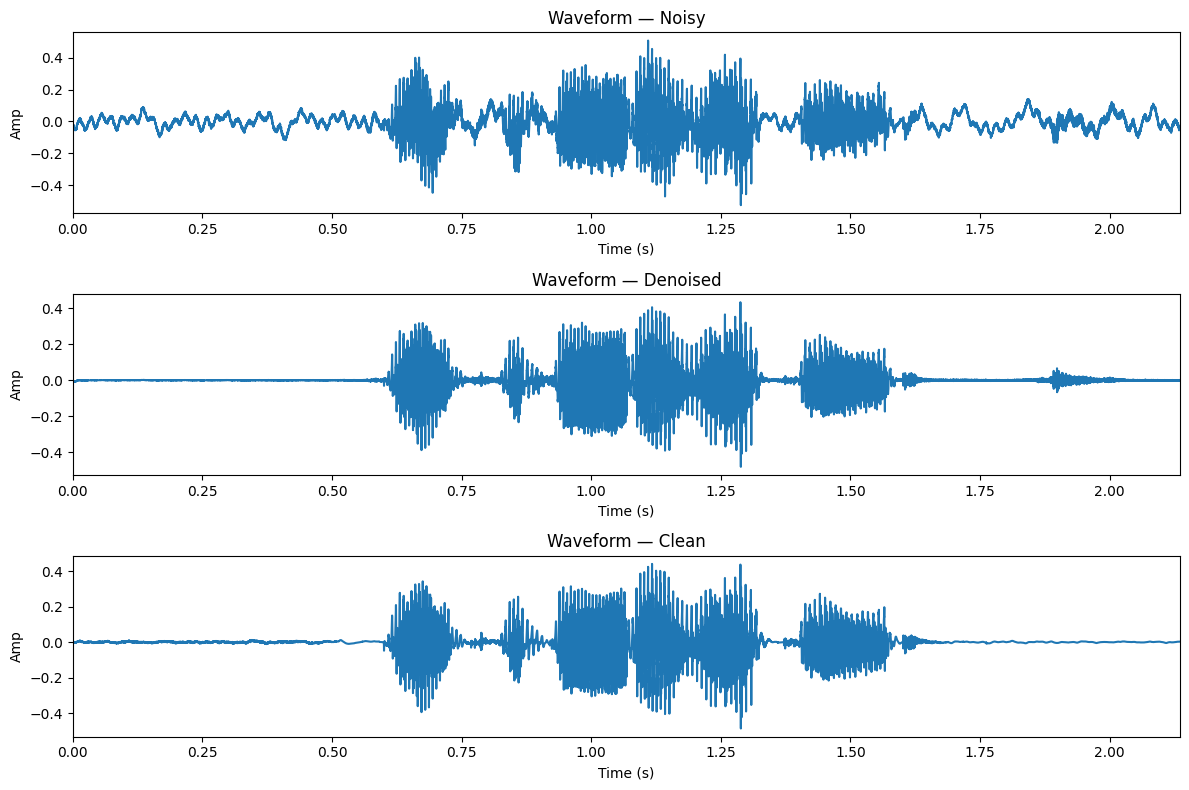

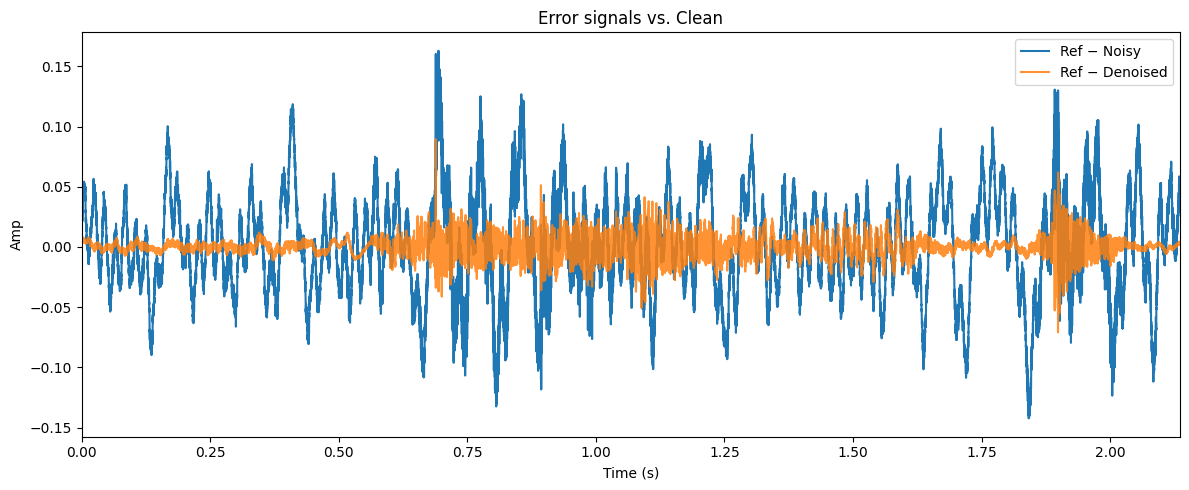

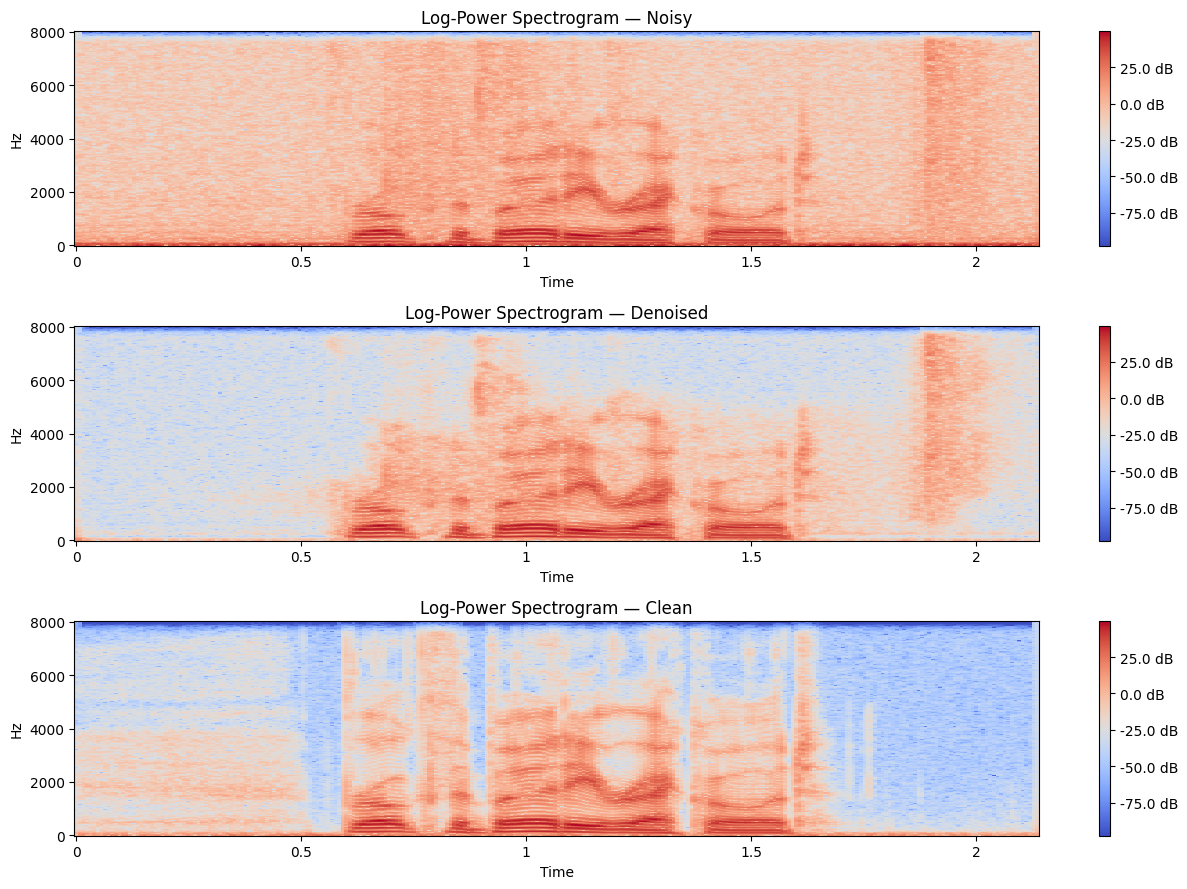

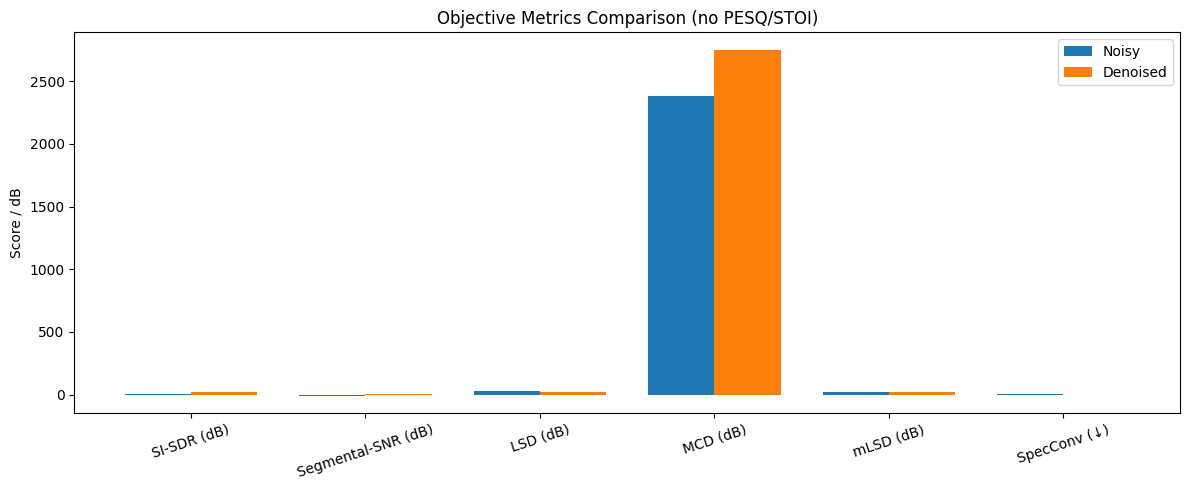

In [ ]:
# ===============================
# Visualization & Evaluation (No PESQ/STOI version + two alternative metrics)
# Replace your existing "Evaluation/Visualization" cell directly
# ===============================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import librosa
import librosa.display

# ---- 1) Utility functions: Metric calculation (no additional libraries required)----
def si_sdr(ref, est, eps=1e-8):
    ref = ref - ref.mean()
    est = est - est.mean()
    t = (np.sum(est*ref) / (np.sum(ref*ref) + eps)) * ref
    n = est - t
    ratio = (np.sum(t*t) + eps) / (np.sum(n*n) + eps)
    return 10.0 * np.log10(ratio + eps)

def segmental_snr(ref, est, sr, frame_ms=20, eps=1e-12):
    N = len(ref)
    L = max(1, int(sr * frame_ms / 1000.0))
    acc, num = 0.0, 0
    for i in range(0, N, L):
        r = ref[i:i+L]; e = est[i:i+L]
        if len(r) < 2: continue
        snr = 10*np.log10((np.sum(r*r)+eps) / (np.sum((r-e)*(r-e))+eps))
        acc += snr; num += 1
    return acc/num if num > 0 else np.nan

def log_spectral_distance_db(ref, est, n_fft=512, hop=128, win_length=512, eps=1e-12):
    R = np.abs(librosa.stft(ref, n_fft=n_fft, hop_length=hop, win_length=win_length)) + eps
    E = np.abs(librosa.stft(est, n_fft=n_fft, hop_length=hop, win_length=win_length)) + eps
    Rdb = 20*np.log10(R); Edb = 20*np.log10(E)
    return np.sqrt(np.mean((Rdb - Edb)**2))

def mcd_db(ref, est, sr, n_mfcc=13, drop_c0=True, lifter=None, eps=1e-12):
    mfcc_r = librosa.feature.mfcc(y=ref, sr=sr, n_mfcc=n_mfcc)
    mfcc_e = librosa.feature.mfcc(y=est, sr=sr, n_mfcc=n_mfcc)
    if lifter:
        lif = 1 + (lifter/2.)*np.sin(np.pi*np.arange(n_mfcc)/lifter)[:, None]
        mfcc_r *= lif; mfcc_e *= lif
    if drop_c0 and mfcc_r.shape[0] > 1:
        mfcc_r = mfcc_r[1:, :]
        mfcc_e = mfcc_e[1:, :]
    T = min(mfcc_r.shape[1], mfcc_e.shape[1])
    if T <= 1: return np.nan
    diff = mfcc_r[:, :T] - mfcc_e[:, :T]
    coef = 10.0/np.log(10.0) * np.sqrt(2.0)  # ≈ 6.14185
    return coef * np.mean(np.sqrt(np.sum(diff*diff, axis=0) + eps))

def mel_lsd_db(ref, est, sr, n_mels=80, n_fft=512, hop=128, win_length=512, eps=1e-12):
    S_r = librosa.feature.melspectrogram(y=ref, sr=sr, n_fft=n_fft, hop_length=hop,
                                         win_length=win_length, n_mels=n_mels, power=2.0) + eps
    S_e = librosa.feature.melspectrogram(y=est, sr=sr, n_fft=n_fft, hop_length=hop,
                                         win_length=win_length, n_mels=n_mels, power=2.0) + eps
    L = min(S_r.shape[1], S_e.shape[1])
    S_r = S_r[:, :L]; S_e = S_e[:, :L]
    Rdb = 10*np.log10(S_r); Edb = 10*np.log10(S_e)
    return np.sqrt(np.mean((Rdb - Edb)**2))

def spectral_convergence(ref, est, n_fft=512, hop=128, win_length=512, eps=1e-12):
    R = np.abs(librosa.stft(ref, n_fft=n_fft, hop_length=hop, win_length=win_length)) + eps
    E = np.abs(librosa.stft(est, n_fft=n_fft, hop_length=hop, win_length=win_length)) + eps
    num = np.linalg.norm(R - E, ord='fro')
    den = np.linalg.norm(R, ord='fro') + eps
    return float(num / den)

# ---- 2) Obtain the array from the previous cell ----
ref = clean.astype(np.float32)
deg_noisy = noisy.astype(np.float32)
deg_deno  = est.astype(np.float32)
sr = int(TARGET_SR)

# ---- 3) Calculation indicators (no PESQ/STOI) ----
def eval_pair(ref, deg, sr):
    return {
        "SI-SDR (dB)":        si_sdr(ref, deg),
        "Segmental-SNR (dB)": segmental_snr(ref, deg, sr),
        "LSD (dB)":           log_spectral_distance_db(ref, deg, n_fft=N_FFT, hop=HOP, win_length=WIN),
        "MCD (dB)":           mcd_db(ref, deg, sr, n_mfcc=13, drop_c0=True, lifter=22),
        "mLSD (dB)":          mel_lsd_db(ref, deg, sr, n_mels=80, n_fft=N_FFT, hop=HOP, win_length=WIN),
        "SpecConv (↓)":       spectral_convergence(ref, deg, n_fft=N_FFT, hop=HOP, win_length=WIN),
    }

metrics_noisy = eval_pair(ref, deg_noisy, sr)
metrics_deno  = eval_pair(ref, deg_deno,  sr)

df = pd.DataFrame([metrics_noisy, metrics_deno], index=["Noisy → Clean", "Denoised → Clean"])

def delta(a, b):
    if a is None or b is None or (isinstance(a, float) and np.isnan(a)) or (isinstance(b, float) and np.isnan(b)):
        return None
    return b - a

improve = {
    "Δ SI-SDR (dB)":   delta(metrics_noisy["SI-SDR (dB)"],        metrics_deno["SI-SDR (dB)"]),
    "Δ SegSNR (dB)":   delta(metrics_noisy["Segmental-SNR (dB)"], metrics_deno["Segmental-SNR (dB)"]),
    "Δ LSD (dB)↓":     delta(metrics_noisy["LSD (dB)"],           metrics_deno["LSD (dB)"]),
    "Δ MCD (dB)↓":     delta(metrics_noisy["MCD (dB)"],           metrics_deno["MCD (dB)"]),
    "Δ mLSD (dB)↓":    delta(metrics_noisy["mLSD (dB)"],          metrics_deno["mLSD (dB)"]),
    "Δ SpecConv↓":     delta(metrics_noisy["SpecConv (↓)"],       metrics_deno["SpecConv (↓)"]),
}
df_improve = pd.DataFrame([improve], index=["Improvement (Denoised − Noisy)"])

with pd.option_context("display.precision", 3):
    print("\n=== Objective Metrics (no PESQ/STOI) ===")
    display(df)
    print("\n=== Improvements (Denoised − Noisy) ===")
    display(df_improve)

# ---- 4) Visualization: Waveforms & Spectra ----
dur = len(ref)/sr
t = np.arange(len(ref))/sr

plt.figure(figsize=(12, 8))
plt.subplot(3,1,1); plt.plot(t, deg_noisy); plt.title("Waveform — Noisy");    plt.xlabel("Time (s)"); plt.ylabel("Amp"); plt.xlim(0, dur)
plt.subplot(3,1,2); plt.plot(t, deg_deno);  plt.title("Waveform — Denoised");  plt.xlabel("Time (s)"); plt.ylabel("Amp"); plt.xlim(0, dur)
plt.subplot(3,1,3); plt.plot(t, ref);       plt.title("Waveform — Clean");     plt.xlabel("Time (s)"); plt.ylabel("Amp"); plt.xlim(0, dur)
plt.tight_layout(); plt.show()

# waveform error
err_noisy = ref - deg_noisy
err_deno  = ref - deg_deno
plt.figure(figsize=(12,5))
plt.plot(t, err_noisy, label="Ref − Noisy")
plt.plot(t, err_deno,  label="Ref − Denoised", alpha=0.85)
plt.title("Error signals vs. Clean"); plt.xlabel("Time (s)"); plt.ylabel("Amp"); plt.xlim(0, dur); plt.legend(); plt.tight_layout(); plt.show()

# Spectrum (logarithmic power spectrum)
def spec_db(y, sr, n_fft=512, hop=128, win_length=512, ref_power=1.0, eps=1e-12):
    S = np.abs(librosa.stft(y, n_fft=n_fft, hop_length=hop, win_length=win_length))**2
    return 10*np.log10(S + eps) - 10*np.log10(ref_power + eps)

ref_pow = np.mean(ref.astype(np.float64)**2) + 1e-12
S_noisy = spec_db(deg_noisy, sr, n_fft=N_FFT, hop=HOP, win_length=WIN, ref_power=ref_pow)
S_deno  = spec_db(deg_deno,  sr, n_fft=N_FFT, hop=HOP, win_length=WIN, ref_power=ref_pow)
S_clean = spec_db(ref,       sr, n_fft=N_FFT, hop=HOP, win_length=WIN, ref_power=ref_pow)

plt.figure(figsize=(13,9))
ax1 = plt.subplot(3,1,1); librosa.display.specshow(S_noisy, sr=sr, hop_length=HOP, x_axis='time', y_axis='linear');  plt.title("Log-Power Spectrogram — Noisy");    plt.colorbar(ax=ax1, format="%.1f dB")
ax2 = plt.subplot(3,1,2); librosa.display.specshow(S_deno,  sr=sr, hop_length=HOP, x_axis='time', y_axis='linear');  plt.title("Log-Power Spectrogram — Denoised");  plt.colorbar(ax=ax2, format="%.1f dB")
ax3 = plt.subplot(3,1,3); librosa.display.specshow(S_clean, sr=sr, hop_length=HOP, x_axis='time', y_axis='linear');  plt.title("Log-Power Spectrogram — Clean");     plt.colorbar(ax=ax3, format="%.1f dB")
plt.tight_layout(); plt.show()

# ---- 5) Indicator comparison bar chart (excluding PESQ/STOI) ----
labels = ["SI-SDR (dB)", "Segmental-SNR (dB)", "LSD (dB)", "MCD (dB)", "mLSD (dB)", "SpecConv (↓)"]
noisy_vals = [metrics_noisy[k] for k in labels]
deno_vals  = [metrics_deno[k]  for k in labels]
x = np.arange(len(labels)); w = 0.38
plt.figure(figsize=(12,5))
plt.bar(x - w/2, noisy_vals, width=w, label="Noisy")
plt.bar(x + w/2, deno_vals,  width=w, label="Denoised")
plt.xticks(x, labels, rotation=18); plt.title("Objective Metrics Comparison (no PESQ/STOI)"); plt.ylabel("Score / dB")
plt.legend(); plt.tight_layout(); plt.show()



=== Per-utterance metrics (head) ===


,N_SI-SDR (dB),N_Segmental-SNR (dB),N_LSD (dB),N_MCD (dB),N_mLSD (dB),N_SpecConv (↓),D_SI-SDR (dB),D_Segmental-SNR (dB),D_LSD (dB),D_MCD (dB),D_mLSD (dB),D_SpecConv (↓),Imp_SI-SDR (dB),Imp_Segmental-SNR (dB),Imp_LSD (dB),Imp_MCD (dB),Imp_mLSD (dB),Imp_SpecConv (↓)
utt,,,,,,,,,,,,,,,,,,
0,15.492,5.336,10.451,926.108,10.573,0.172,24.759,13.008,8.031,1300.813,7.040,0.058,9.267,7.672,-2.420,374.705,-3.533,-0.115
1,11.320,5.169,7.210,735.662,6.721,0.288,22.563,14.959,7.965,1083.702,6.906,0.069,11.243,9.790,0.755,348.041,0.184,-0.219
2,6.732,-1.135,11.477,1133.939,10.698,0.515,21.862,13.536,9.235,1446.751,8.150,0.080,15.129,14.670,-2.242,312.812,-2.548,-0.436
3,1.856,-3.332,19.278,2266.383,17.645,0.855,13.997,9.111,14.571,2546.911,12.649,0.170,12.141,12.444,-4.707,280.528,-4.995,-0.685
4,16.870,10.140,15.504,1507.698,14.047,0.138,21.978,14.206,10.403,1496.197,8.677,0.067,5.108,4.066,-5.101,-11.501,-5.370,-0.071



=== Dataset Mean (Noisy vs. Denoised) ===


,Noisy mean,Denoised mean
N_SI-SDR (dB),8.453,NaN
N_Segmental-SNR (dB),-1.001,NaN
N_LSD (dB),16.919,NaN
N_MCD (dB),1700.886,NaN
N_mLSD (dB),15.693,NaN
N_SpecConv (↓),0.480,NaN
D_SI-SDR (dB),NaN,17.784
D_Segmental-SNR (dB),NaN,8.851
D_LSD (dB),NaN,11.947
D_MCD (dB),NaN,2145.582



=== Dataset Std (Noisy vs. Denoised) ===


,Noisy std,Denoised std
N_SI-SDR (dB),5.619,NaN
N_Segmental-SNR (dB),6.267,NaN
N_LSD (dB),5.992,NaN
N_MCD (dB),627.223,NaN
N_mLSD (dB),6.084,NaN
N_SpecConv (↓),0.316,NaN
D_SI-SDR (dB),NaN,4.708
D_Segmental-SNR (dB),NaN,3.871
D_LSD (dB),NaN,2.840
D_MCD (dB),NaN,753.357



=== Improvements (Denoised − Noisy) Mean ===


,Improvement mean
Imp_SI-SDR (dB),9.331
Imp_Segmental-SNR (dB),9.851
Imp_LSD (dB),-4.972
Imp_MCD (dB),444.696
Imp_mLSD (dB),-5.135
Imp_SpecConv (↓),-0.343



=== Improvements (Denoised − Noisy) Std ===


,Improvement std
Imp_SI-SDR (dB),4.505
Imp_Segmental-SNR (dB),4.425
Imp_LSD (dB),3.761
Imp_MCD (dB),412.401
Imp_mLSD (dB),3.887
Imp_SpecConv (↓),0.280


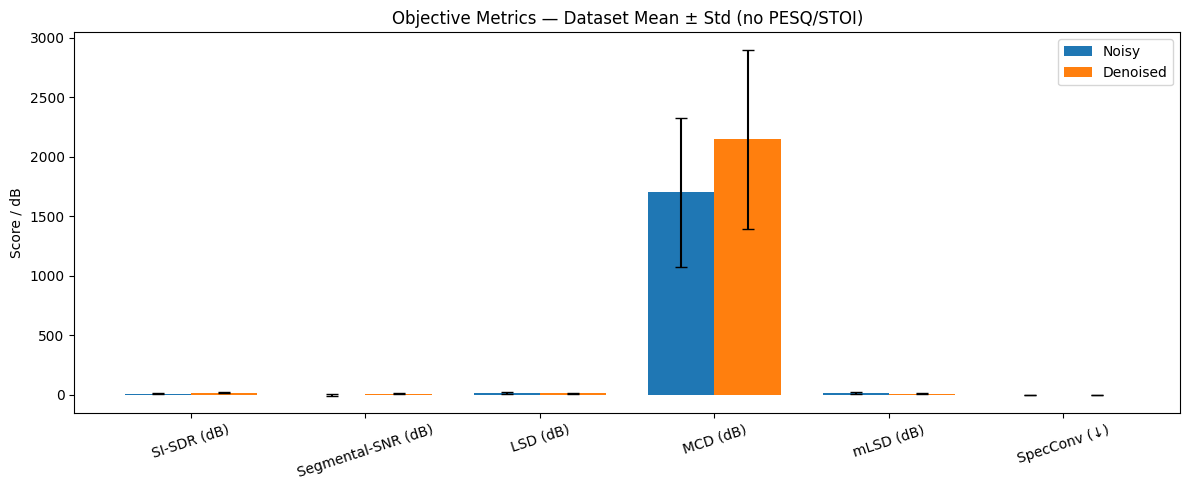

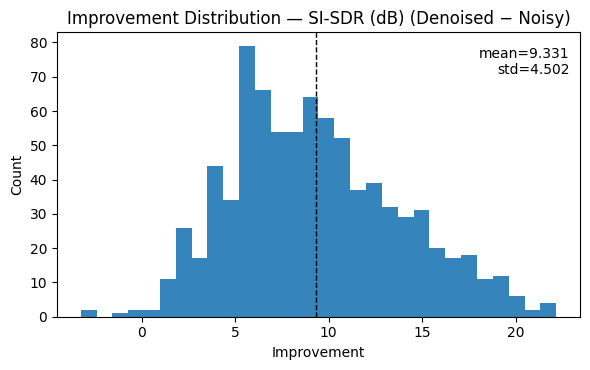

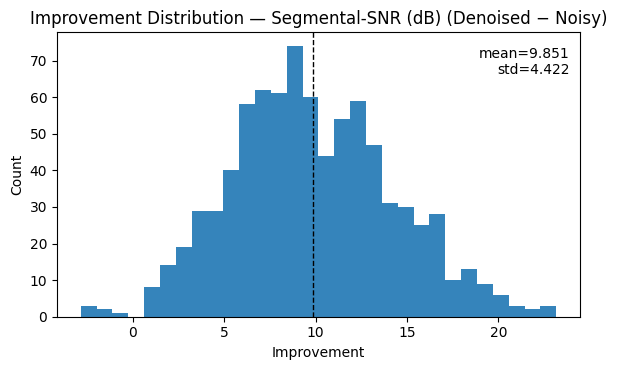

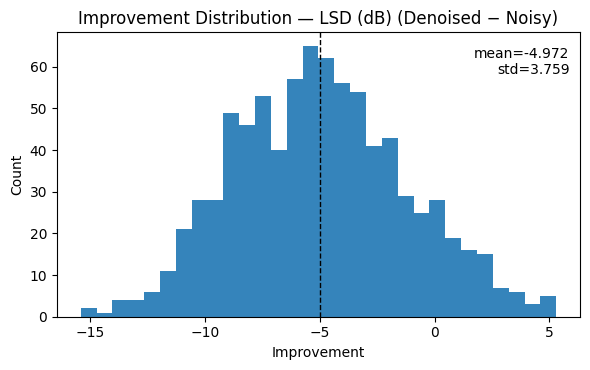

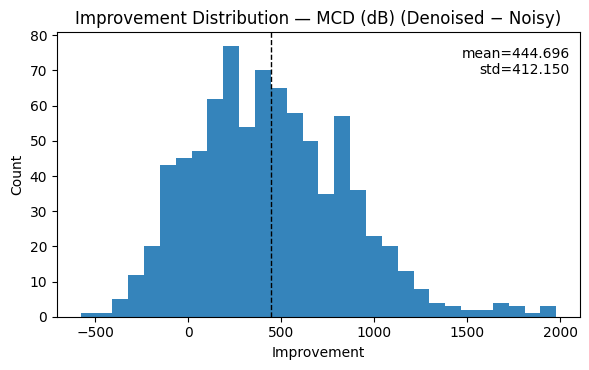

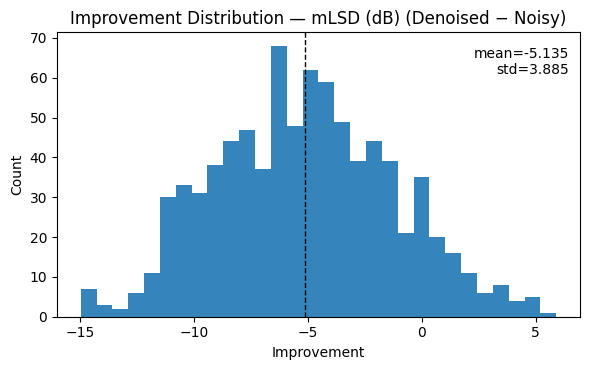

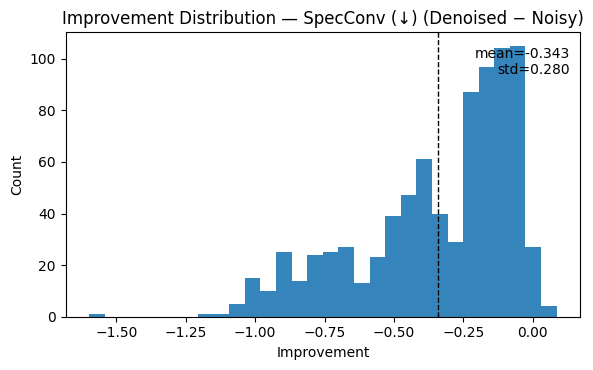

In [ ]:
# ===============================
# Full test set evaluation (no PESQ/STOI) - multi-sample averaging
# ===============================
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import librosa
import librosa.display
import torch

def si_sdr(ref, est, eps=1e-8):
    ref = ref - ref.mean()
    est = est - est.mean()
    t = (np.sum(est*ref) / (np.sum(ref*ref) + eps)) * ref
    n = est - t
    ratio = (np.sum(t*t) + eps) / (np.sum(n*n) + eps)
    return 10.0 * np.log10(ratio + eps)

def segmental_snr(ref, est, sr, frame_ms=20, eps=1e-12):
    N = len(ref)
    L = max(1, int(sr * frame_ms / 1000.0))
    acc, num = 0.0, 0
    for i in range(0, N, L):
        r = ref[i:i+L]; e = est[i:i+L]
        if len(r) < 2: 
            continue
        snr = 10*np.log10((np.sum(r*r)+eps) / (np.sum((r-e)*(r-e))+eps))
        acc += snr; num += 1
    return acc/num if num > 0 else np.nan

def log_spectral_distance_db(ref, est, n_fft=512, hop=128, win_length=512, eps=1e-12):
    R = np.abs(librosa.stft(ref, n_fft=n_fft, hop_length=hop, win_length=win_length)) + eps
    E = np.abs(librosa.stft(est, n_fft=n_fft, hop_length=hop, win_length=win_length)) + eps
    Rdb = 20*np.log10(R); Edb = 20*np.log10(E)
    return np.sqrt(np.mean((Rdb - Edb)**2))

def mcd_db(ref, est, sr, n_mfcc=13, drop_c0=True, lifter=22, eps=1e-12):
    mfcc_r = librosa.feature.mfcc(y=ref, sr=sr, n_mfcc=n_mfcc)
    mfcc_e = librosa.feature.mfcc(y=est, sr=sr, n_mfcc=n_mfcc)
    if lifter:
        lif = 1 + (lifter/2.)*np.sin(np.pi*np.arange(n_mfcc)/lifter)[:, None]
        mfcc_r *= lif; mfcc_e *= lif
    if drop_c0 and mfcc_r.shape[0] > 1:
        mfcc_r = mfcc_r[1:, :]
        mfcc_e = mfcc_e[1:, :]
    T = min(mfcc_r.shape[1], mfcc_e.shape[1])
    if T <= 1: 
        return np.nan
    diff = mfcc_r[:, :T] - mfcc_e[:, :T]
    coef = 10.0/np.log(10.0) * np.sqrt(2.0)  # ≈6.14185
    return coef * np.mean(np.sqrt(np.sum(diff*diff, axis=0) + eps))

def mel_lsd_db(ref, est, sr, n_mels=80, n_fft=512, hop=128, win_length=512, eps=1e-12):
    S_r = librosa.feature.melspectrogram(y=ref, sr=sr, n_fft=n_fft, hop_length=hop,
                                         win_length=win_length, n_mels=n_mels, power=2.0) + eps
    S_e = librosa.feature.melspectrogram(y=est, sr=sr, n_fft=n_fft, hop_length=hop,
                                         win_length=win_length, n_mels=n_mels, power=2.0) + eps
    L = min(S_r.shape[1], S_e.shape[1])
    S_r = S_r[:, :L]; S_e = S_e[:, :L]
    Rdb = 10*np.log10(S_r); Edb = 10*np.log10(S_e)
    return np.sqrt(np.mean((Rdb - Edb)**2))

def spectral_convergence(ref, est, n_fft=512, hop=128, win_length=512, eps=1e-12):
    R = np.abs(librosa.stft(ref, n_fft=n_fft, hop_length=hop, win_length=win_length)) + eps
    E = np.abs(librosa.stft(est, n_fft=n_fft, hop_length=hop, win_length=win_length)) + eps
    num = np.linalg.norm(R - E, ord='fro')
    den = np.linalg.norm(R, ord='fro') + eps
    return float(num / den)

METRIC_KEYS = ["SI-SDR (dB)", "Segmental-SNR (dB)", "LSD (dB)", "MCD (dB)", "mLSD (dB)", "SpecConv (↓)"]

def eval_pair(ref, deg, sr):
    return {
        "SI-SDR (dB)":        si_sdr(ref, deg),
        "Segmental-SNR (dB)": segmental_snr(ref, deg, sr),
        "LSD (dB)":           log_spectral_distance_db(ref, deg, n_fft=N_FFT, hop=HOP, win_length=WIN),
        "MCD (dB)":           mcd_db(ref, deg, sr, n_mfcc=13, drop_c0=True, lifter=22),
        "mLSD (dB)":          mel_lsd_db(ref, deg, sr, n_mels=80, n_fft=N_FFT, hop=HOP, win_length=WIN),
        "SpecConv (↓)":       spectral_convergence(ref, deg, n_fft=N_FFT, hop=HOP, win_length=WIN),
    }

@torch.no_grad()
def evaluate_dataset(model, dataset, device):
    model.eval()
    rows = []
    for i in range(len(dataset)):
        noisy, clean = dataset[i]                 # tensors: [T], [T]
        x = noisy.unsqueeze(0).to(device)         # [1,T]
        # STFT & 推理
        mag_n, ph_n = stft_mag_phase(x)
        inp = torch.log1p(mag_n).unsqueeze(1)     # [1,1,F,Tspec]
        inp, pads = pad_to_multiple(inp, mul=16)
        mask = model(inp)
        mask = unpad(mask, pads)
        est_mag = mask.squeeze(1) * mag_n
        est = istft_from_mag_phase(est_mag, ph_n) # [1,T]

        # 对齐并转 numpy
        L = min(est.shape[-1], clean.shape[-1])
        est_np   = est[..., :L].squeeze().cpu().numpy().astype(np.float32)
        clean_np = clean[:L].cpu().numpy().astype(np.float32)
        noisy_np = noisy[:L].cpu().numpy().astype(np.float32)

        m_noisy = eval_pair(clean_np, noisy_np, TARGET_SR)
        m_deno  = eval_pair(clean_np, est_np,   TARGET_SR)
        rows.append({"utt": i, **{f"N_{k}": v for k, v in m_noisy.items()},
                           **{f"D_{k}": v for k, v in m_deno.items()}})
    df = pd.DataFrame(rows).set_index("utt")

    for k in METRIC_KEYS:
        df[f"Imp_{k}"] = df[f"D_{k}"] - df[f"N_{k}"]

    summary_mean = pd.concat([
        df[[f"N_{k}" for k in METRIC_KEYS]].mean().rename("Noisy mean"),
        df[[f"D_{k}" for k in METRIC_KEYS]].mean().rename("Denoised mean"),
    ], axis=1)
    summary_std = pd.concat([
        df[[f"N_{k}" for k in METRIC_KEYS]].std().rename("Noisy std"),
        df[[f"D_{k}" for k in METRIC_KEYS]].std().rename("Denoised std"),
    ], axis=1)
    imp_mean = df[[f"Imp_{k}" for k in METRIC_KEYS]].mean().rename("Improvement mean")
    imp_std  = df[[f"Imp_{k}" for k in METRIC_KEYS]].std().rename("Improvement std")

    return df, summary_mean, summary_std, imp_mean, imp_std

df_all, summary_mean, summary_std, imp_mean, imp_std = evaluate_dataset(model, test_ds, DEVICE)

with pd.option_context("display.precision", 3):
    print("\n=== Per-utterance metrics (head) ===")
    display(df_all.head())
    print("\n=== Dataset Mean (Noisy vs. Denoised) ===")
    display(summary_mean)
    print("\n=== Dataset Std (Noisy vs. Denoised) ===")
    display(summary_std)
    print("\n=== Improvements (Denoised − Noisy) Mean ===")
    display(imp_mean.to_frame())
    print("\n=== Improvements (Denoised − Noisy) Std ===")
    display(imp_std.to_frame())

labels = METRIC_KEYS
noisy_means  = [summary_mean.loc[f"N_{k}", "Noisy mean"]      for k in labels]
deno_means   = [summary_mean.loc[f"D_{k}", "Denoised mean"]   for k in labels]
noisy_stds   = [summary_std.loc[f"N_{k}", "Noisy std"]        for k in labels]
deno_stds    = [summary_std.loc[f"D_{k}", "Denoised std"]     for k in labels]

x = np.arange(len(labels)); w = 0.38
plt.figure(figsize=(12,5))
plt.bar(x - w/2, noisy_means,  yerr=noisy_stds,  width=w, label="Noisy",    capsize=4)
plt.bar(x + w/2, deno_means,   yerr=deno_stds,   width=w, label="Denoised", capsize=4)
plt.xticks(x, labels, rotation=18)
plt.title("Objective Metrics — Dataset Mean ± Std (no PESQ/STOI)")
plt.ylabel("Score / dB")
plt.legend()
plt.tight_layout(); plt.show()

for k in labels:
    vals = df_all[f"Imp_{k}"].dropna().values
    plt.figure(figsize=(6,3.8))
    plt.hist(vals, bins=30, alpha=0.9)
    plt.title(f"Improvement Distribution — {k} (Denoised − Noisy)")
    plt.xlabel("Improvement"); plt.ylabel("Count")
    m, s = np.mean(vals), np.std(vals)
    plt.axvline(m, color='k', linestyle='--', linewidth=1)
    plt.text(0.98, 0.95, f"mean={m:.3f}\nstd={s:.3f}", transform=plt.gca().transAxes,
             ha="right", va="top")
    plt.tight_layout(); plt.show()

# ---- (Optional) Save the CSV result locally ----
# df_all.to_csv("per_utterance_metrics.csv", index=True)
# summary_mean.to_csv("dataset_mean.csv"); summary_std.to_csv("dataset_std.csv")
# imp_mean.to_frame().to_csv("improvement_mean.csv"); imp_std.to_frame().to_csv("improvement_std.csv")
